<a href="https://colab.research.google.com/github/m7-code/AI_Models/blob/main/Grad_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
SAVE_DIR = Path('/content/drive/MyDrive/Mughira Asad')
model_path = SAVE_DIR / 'best_model.pth'

print("Folder exists:", SAVE_DIR.exists())
print("Model file exists:", model_path.exists())
if SAVE_DIR.exists():
    print("Folder ke andar files:", list(SAVE_DIR.iterdir()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder exists: True
Model file exists: True
Folder ke andar files: [PosixPath('/content/drive/MyDrive/Mughira Asad/best_model.pth')]


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

!pip install -q timm opencv-python-headless
import timm
import cv2

def load_saved_model(model_path, device):
    model = timm.create_model('efficientnet_b2', pretrained=False)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print(f"Model loaded from: {model_path}")
    return model

model = load_saved_model(model_path, device)

Device: cpu
Model loaded from: /content/drive/MyDrive/Mughira Asad/best_model.pth


In [ ]:
from google.colab import files

uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]
print("Uploaded:", test_image_path)

Saving pneumonia.png to pneumonia (1).png
Uploaded: pneumonia (1).png


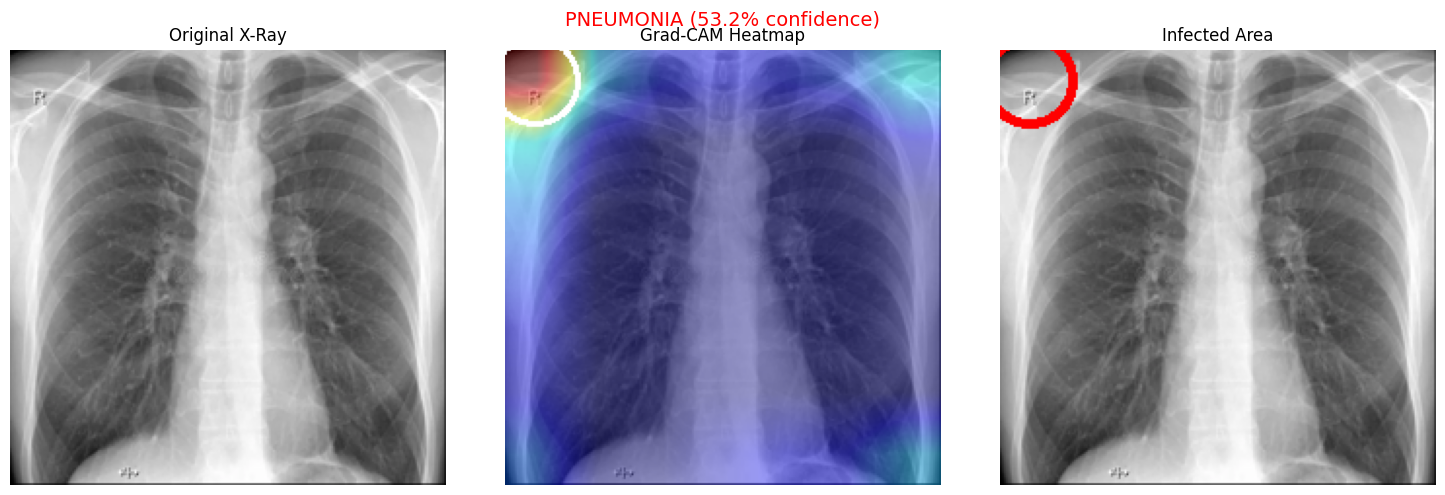

Result: PNEUMONIA | Confidence: 53.2%


('PNEUMONIA',
 53.18214297294617,
 array([[0.9999999 , 0.9999999 , 0.9999999 , ..., 0.38174716, 0.38174716,
         0.38174716],
        [0.9999999 , 0.9999999 , 0.9999999 , ..., 0.38174716, 0.38174716,
         0.38174716],
        [0.9999999 , 0.9999999 , 0.9999999 , ..., 0.38174716, 0.38174716,
         0.38174716],
        ...,
        [0.21988867, 0.21988867, 0.21988867, ..., 0.30019212, 0.30019212,
         0.30019212],
        [0.21988867, 0.21988867, 0.21988867, ..., 0.30019212, 0.30019212,
         0.30019212],
        [0.21988867, 0.21988867, 0.21988867, ..., 0.30019212, 0.30019212,
         0.30019212]], dtype=float32))

In [ ]:
def overlay_gradcam_v2(image_pil, cam, threshold=0.65, max_circles=2, min_area=150):
    """
    Improved version: sirf sabse zyada activated (tight) regions par circles banata hai,
    poore chest ko cover nahi karta.
    """
    img = np.array(image_pil.resize((224, 224)).convert('RGB'))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    circled = img.copy()

    mask = np.uint8(cam >= threshold) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # chote/noise contours hata do, baqi ko area ke hisaab se sort karo
    contours = [c for c in contours if cv2.contourArea(c) >= min_area]
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:max_circles]

    for c in contours:
        (cx, cy), radius = cv2.minEnclosingCircle(c)
        center = (int(cx), int(cy))
        radius = max(int(radius), 12)
        cv2.circle(circled, center, radius, (255, 0, 0), 3)
        cv2.circle(overlay, center, radius, (255, 255, 255), 2)

    return overlay, circled


def predict_with_gradcam_v2(model, image_path, device, threshold=0.65, max_circles=2):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    classes = ['NORMAL', 'PNEUMONIA']

    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    pred = classes[probs.argmax().item()]
    conf = probs.max().item() * 100

    gradcam = GradCAM(model, model.conv_head)
    cam, _ = gradcam.generate(tensor, class_idx=1)

    overlay, circled = overlay_gradcam_v2(
        img, cam, threshold=threshold, max_circles=max_circles
    ) if pred == 'PNEUMONIA' else (np.array(img.resize((224,224))), np.array(img.resize((224,224))))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.resize((224, 224))); axes[0].set_title("Original X-Ray"); axes[0].axis('off')
    axes[1].imshow(overlay); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis('off')
    axes[2].imshow(circled); axes[2].set_title("Infected Area" if pred == 'PNEUMONIA' else "No Infection"); axes[2].axis('off')
    fig.suptitle(f"{pred} ({conf:.1f}% confidence)", fontsize=14, color='red' if pred == 'PNEUMONIA' else 'green')
    plt.tight_layout()
    plt.show()

    print(f"Result: {pred} | Confidence: {conf:.1f}%")
    return pred, conf, cam


predict_with_gradcam_v2(model, test_image_path, device, threshold=0.65, max_circles=2)

In [ ]:
from pathlib import Path
from datetime import datetime
import json

# Drive already mounted hona chahiye (agar nahi to: drive.mount('/content/drive'))
SAVE_DIR = Path('/content/drive/MyDrive/pneumonia_models1')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sirf model weights save karo (FastAPI ke liye yehi chahiye)
torch.save(model.state_dict(), SAVE_DIR / 'best_model.pth')

# Backup copy bhi (timestamp ke sath) — accidental overwrite se bachne ke liye
torch.save(model.state_dict(), SAVE_DIR / f'best_model_{timestamp}.pth')

print(f"Model saved to: {SAVE_DIR / 'best_model.pth'}")

Model saved to: /content/drive/MyDrive/pneumonia_models1/best_model.pth


In [ ]:
from google.colab import files

files.download(str(SAVE_DIR / 'best_model.pth'))
print("Download shuru ho gayi — best_model.pth save ho jayegi.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download shuru ho gayi — best_model.pth save ho jayegi.
